# Electron Absorption

## Imports

In [23]:
import numpy as np
import pandas as pd
import re

from scipy.interpolate import RegularGridInterpolator
from scipy.integrate import quad, quad_vec

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


## Loading and Parsing Data

### Loading Trajectories

In [2]:
def load_trajectories(filepath):
    """
    Parse trajectory files (.dat) from CASINO.

    Electron metadata:
    BackScattered, Transmitted, Detected, Displayed, Nb Collisions, Max Depth,
    Mean Free Path, Mean dE/dS, Mean Phi, Mean Theta, Mean Position

    Columns:
    X, Y, Z, Rx, Ry, Rz, Energy, Region
    """

    trajectories = []
    
    with open(filepath, 'r') as f:
        content = f.read()

    blocks = re.split(r'-{10,}', content)

    for block in blocks:
        lines = [l for l in block.strip().splitlines() if l.strip()]
        if not lines:
            continue

        traj_match = re.search(r'Trajectory\s+(\d+)', block)
        if not traj_match:
            continue
        traj_id = int(traj_match.group(1))

        meta = {}
        meta_match = re.search(
            r'(yes|no)\s+(yes|no)\s+(yes|no)\s+(yes|no)\s+'
            r'(\d+)\s+([\d.]+)\s+([\d.]+)\s+([\d.eE+\-]+)\s+'
            r'([\d.eE+\-]+)\s+([\d.eE+\-]+)\s+\(([\d.,\-]+)\)',
            block
        )
        if meta_match:
            g = meta_match.groups()
            meta = {
                'traj_id':       traj_id,
                'backscattered': g[0] == 'yes',
                'transmitted':   g[1] == 'yes',
                'detected':      g[2] == 'yes',
                'displayed':     g[3] == 'yes',
                'nb_collisions': int(g[4]),
                'max_depth':     float(g[5]),
                'mean_free_path':float(g[6]),
                'mean_dE_dS':    float(g[7]),
                'mean_phi':      float(g[8]),
                'mean_theta':    float(g[9]),
                'mean_position': list(map(float, g[10].split(','))),
            }

        # Extract data rows (lines that start with a number)
        data_rows = []
        for line in lines:
            stripped = line.strip()
            # skip header/label lines
            if stripped.startswith('X') or stripped.startswith('Back') \
               or stripped.startswith('Traj') or stripped.startswith('yes') \
               or stripped.startswith('no'):
                continue
            try:
                vals = list(map(float, stripped.split()))
                if len(vals) == 8:
                    data_rows.append(vals)
            except ValueError:
                continue

        if data_rows:
            df = pd.DataFrame(data_rows,
                              columns=['X', 'Y', 'Z', 'Rx', 'Ry', 'Rz', 'Energy', 'Region'])
            trajectories.append({'meta': meta, 'df': df})

    return trajectories


### Calculating Energy Depositions
Returns a list of positions where energy losses occur and how much energy was lost

In [3]:
def energy_deposition(trajectories):
    """
    Compute energy deposited at each step.

    dE = energy[i] - energy[i-1]
    """

    all_positions = []
    all_dE = []

    for traj in trajectories:
        df = traj['df']
        if len(df) < 2:
            continue

        pos = df[['X', 'Y', 'Z']].values
        E = df['Energy'].values

        dE = np.diff(E) * -1
        points = pos[1:]

        all_positions.append(points)
        all_dE.append(dE)
    
    positions = np.vstack(all_positions)
    dE_vals = np.concatenate(all_dE)

    return positions, dE_vals

In [4]:
def query_energy_at_points(positions, dE, query_points, bins=200):
    """
    Build a 3D energy deposition grid and interpolate at query_points.
    
    Args:
        positions:    (N, 3) array of deposition midpoints (nm)
        dE:           (N,)   array of deposited energy (eV)
        query_points: (M, 3) array of XYZ locations to sample
        bins:         voxel resolution

    Returns:
        absorbed: (M,) interpolated energy values
    """
    

    energy_map, edges = np.histogramdd(positions, bins=bins, weights=dE)
    centers = [(e[:-1] + e[1:]) / 2 for e in edges]

    interp = RegularGridInterpolator(centers, energy_map,
                                     method='linear',
                                     bounds_error=False,
                                     fill_value=0.0)
    return interp(query_points)

In [5]:
def plot_energy_deposition(positions, dE, bins=50, min_energy_percentile=10):
    """
    3D Scatter plot of energy deposition locations.
    """
    # Bin into 3D voxels first to reduce number of points plotted
    energy_map, edges = np.histogramdd(positions, bins=bins, weights=dE)
    centers = [(e[:-1] + e[1:]) / 2 for e in edges]

    # Build coordinate grid
    cx, cy, cz = np.meshgrid(*centers, indexing='ij')

    # Flatten
    x_flat = cx.ravel()
    y_flat = cy.ravel()
    z_flat = cz.ravel()
    e_flat = energy_map.ravel()

    # Filter out empty/low-energy voxels
    threshold = np.percentile(e_flat[e_flat > 0], min_energy_percentile)
    mask = e_flat > threshold

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    sc = ax.scatter(
        x_flat[mask], y_flat[mask], z_flat[mask],
        c=e_flat[mask],
        cmap='hot',
        s=20,
        alpha=0.6,
        norm=plt.Normalize(vmin=e_flat[mask].min(), vmax=e_flat[mask].max())
    )

    cbar = plt.colorbar(sc, ax=ax, pad=0.1, shrink=0.6)
    cbar.set_label('Energy Deposited (keV)', fontsize=11)

    ax.set_xlabel('X (nm)')
    ax.set_ylabel('Y (nm)')
    ax.set_zlabel('Z (nm)')
    ax.set_title('3D Energy Deposition Map', fontsize=13)
    ax.invert_zaxis()

    plt.tight_layout()
    plt.show()

In [165]:
def plot_energy_dep_xz(positions, dE, bins=50):
    """
    2D XZ projection of energy deposition (integrated over Y).
    """

    # 3D binning
    energy_map, edges = np.histogramdd(positions, bins=bins, weights=dE)

    # Project onto XZ plane by summing over Y-axis
    energy_xz = energy_map.sum(axis=1)

    # Get bin centers for X and Z
    x_centers = (edges[0][:-1] + edges[0][1:]) / 2
    z_centers = (edges[2][:-1] + edges[2][1:]) / 2

    plt.figure(figsize=(8, 6))

    im = plt.pcolormesh(
        x_centers,
        z_centers,
        energy_xz.T,
        cmap='hot',
        shading='auto',
    )

    cbar = plt.colorbar(im)
    cbar.set_label('Energy Deposited (keV)', fontsize=11)

    plt.xlabel('X (nm)')
    plt.ylabel('Z (nm)')
    plt.gca().invert_yaxis()

    plt.tight_layout()
    plt.show()

In [7]:
trajs = load_trajectories('data/2205Test_Trj_58keV_50umBD.dat')
print(f"Loaded {len(trajs)} trajectories")
print(f"Trajectory 0 metadata: {trajs[0]['meta']}")
print(trajs[0]['df'].head())

positions, dE = energy_deposition(trajs)
print(f"\nTotal deposition steps: {len(dE)}")
print(f"Total energy deposited: {dE.sum():.4f} keV")
print(f"Total energy deposited per electron: {dE.sum() / len(trajs):4f} keV")

query_points = np.array([
    [3943.0, -280.0, 50.0],
    [3945.0, -278.0, 130.0],
])
absorbed = query_energy_at_points(positions, dE, query_points)
for pt, val in zip(query_points, absorbed):
    print(f"  Location {pt} -> {val:.6f} keV")

Loaded 51 trajectories
Trajectory 0 metadata: {'traj_id': 0, 'backscattered': False, 'transmitted': False, 'detected': False, 'displayed': True, 'nb_collisions': 1486, 'max_depth': 2959.45, 'mean_free_path': 0.0, 'mean_dE_dS': -0.00899422, 'mean_phi': 3.14951, 'mean_theta': 0.0990671, 'mean_position': [4871.93, 753.187, 1733.8]}
         X        Y         Z   Rx   Ry   Rz   Energy  Region
0  3943.63 -283.975   0.00000  0.0  0.0  1.0  58.0000  2205.0
1  3943.63 -283.975   5.99972 -0.0 -0.0  1.0  57.9817  2205.0
2  3943.63 -283.975  24.95510  0.0 -0.0  1.0  57.9237  2205.0
3  3943.63 -283.975  31.89330  0.0 -0.0  1.0  57.9024  2205.0
4  3943.63 -283.975  53.20240  0.0  0.0  1.0  57.8372  2205.0

Total deposition steps: 65442
Total energy deposited: 2571.7307 keV
Total energy deposited per electron: 50.426092 keV
  Location [3943. -280.   50.] -> 0.083265 keV
  Location [3945. -278.  130.] -> 0.058902 keV


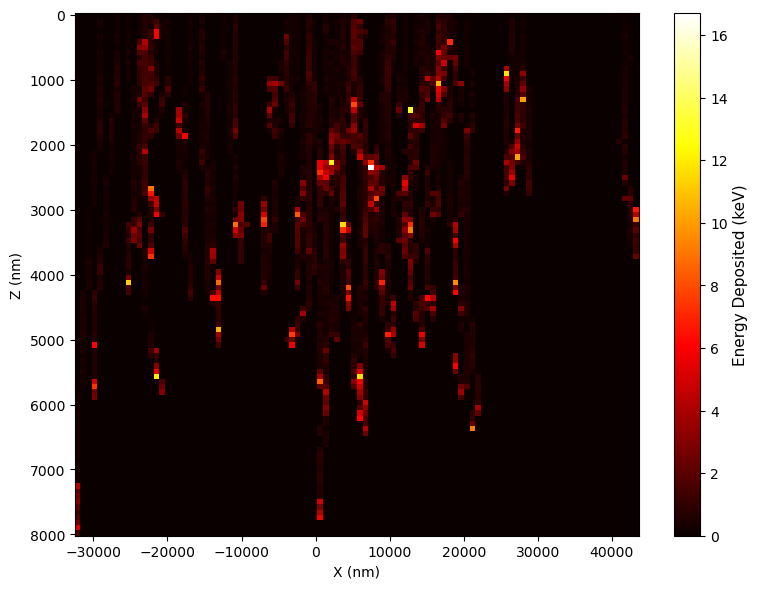

In [166]:
plot_energy_dep_xz(positions, dE, bins=100)

## Simple Finite Difference Melt Pool Simulation
This simulation uses a cylindrical axisymmetric model.

Boundary Conditions: 
- Top Surface is insulated
- Deep thickness is held at ambient temperature
- Symmetric about the center
- Far radially is held at ambient temperature

### Grid size and dt calculations

In [ ]:
k = 20
rho = 7600
cp = 600
alpha = k / (rho * cp)

r_beam = 150e-6  # m
t_dwell = 25e-3  # s

# Domain (How big the simulation area is)
r_max = 5 * r_beam 
z_max = 5 * r_beam 

# Try different resolutions
for N in [50, 100, 200]:
    dr = r_max / N
    dz = z_max / N
    ds = min(dr, dz)
    dt = 0.2 * ds**2 / alpha
    n_steps = t_dwell / dt
    print(f"N={N:4d} | dz={dz*1e6:.1f} µm | dt={dt:.2e} s | steps={n_steps:.2e}")

    # Fine z grid to resolve deposition
Nz = 500   # dz = 750µm/500 = 1.5 µm — 5 bins in deposition zone
Nr = 100   # dr = 750µm/100 = 7.5 µm — sufficient for radial

# dt constrained by finest grid dimension
dz = z_max / Nz   # 1.5 µm
dr = r_max / Nr   # 7.5 µm
dt = 0.2 * min(dz, dr)**2 / alpha  # constrained by dz

n_steps = t_dwell / dt
print(f"dz={dz*1e6:.1f} µm | dr={dr*1e6:.1f} µm | dt={dt:.2e} s | steps={n_steps:.2e}")

N=  50 | dz=15.0 µm | dt=1.03e-05 s | steps=2.44e+03
N= 100 | dz=7.5 µm | dt=2.57e-06 s | steps=9.75e+03
N= 200 | dz=3.7 µm | dt=6.41e-07 s | steps=3.90e+04
dz=1.5 µm | dr=7.5 µm | dt=1.03e-07 s | steps=2.44e+05


### Heat Source and Heat Solve Functions

In [117]:
def build_heat_source_2d(positions, dE, z_max, r_max, Nz, Nr, beam_area, beam_current, beam_energy_eV, r_beam):
    """
    Builds 2D axisymmetric volumetric heat source q[iz, ir] [W/m3]
    Top-hat radial profile, Monte Carlo z profile
    """

    # Z profile
    z = positions[:, 2]
    bins = np.linspace(0, z_max, Nz+1)
    hist, _ = np.histogram(z, bins=bins, weights=dE)

    dz = z_max / Nz
    total_sim_energy = np.sum(dE)

    beam_power = beam_current * beam_energy_eV # W
    scale = beam_power / total_sim_energy
    q_z = hist * scale / (beam_area * dz)

    # Radial profile
    dr = r_max / Nr
    r_centers = (np.arange(Nr) + 0.5) * dr

    # 2D Heat Source: top-hat in r, Monte Carlo in z
    radial_mask = (r_centers <= r_beam).astype(float)
    q_2d = np.outer(q_z, radial_mask)

    z_centers = (np.arange(Nz) + 0.5) * dz

    return z_centers, r_centers, q_2d

def solve_heat_2d(z, r, q, k, rho, cp, t_max, T_amb=293.15):
    """
    Explicit finite difference solver for 2D axisymmetric heat equation.

    dT/dt = alpha * (d²T/dz² + 1/r * d/dr(r * dT/dr)) + q/(rho*cp)

    Grid: T[iz, ir]
    BCs:
        z=0 (surface): dT/dz = 0 (insulated)
        z=-1 (bulk): T = t_amb (fixed)
        r=0 (axis): dT/dr = 0 (symmetry)
        r=-1 (far field): T = t_amb (fixed)
    """
    Nz = len(z)
    Nr = len(r)

    dz = z[1] - z[0]
    dr = r[1] - r[0]

    alpha = k / (rho * cp)
    dt = 0.2 * min(dz, dr)**2 / alpha
    
    # Stability coefficients
    rz = alpha * dt / dz**2
    rr = alpha * dt / dr**2

    r_plus = r + 0.5 * dr
    r_minus = r - 0.5 * dr

    heat_coeff = dt / (rho * cp)

    T = np.full((Nz, Nr), T_amb)

    t = 0.0
    n_steps = int(t_max / dt) + 1
    print(f"dt={dt:.3e} s | steps={n_steps} | grid=({Nz}x{Nr})")

    while t < t_max:
        T_new = T + heat_coeff * q

        # Z diffusion
        T_new[1:-1, :] += rz * (T[2:, :] - 2*T[1:-1, :] + T[:-2, :])
        
        # r diffusion
        T_new[:, 1:-1] += rr * (
            r_plus[1:-1]  * T[:, 2:]   -
            (r_plus[1:-1] + r_minus[1:-1]) * T[:, 1:-1] +
            r_minus[1:-1] * T[:, :-2]
        ) / r[1:-1]

        T_new[0, :]  = T_new[1, :]   # insulated surface (z=0)
        T_new[-1, :] = T_amb         # deep bulk (z=z_max)
        T_new[:, -1] = T_amb         # far field (r=r_max)

        T = T_new
        t += dt

    return T

### Run simulation

In [ ]:
## Parameters
# Material parameters
k = 20 # W/mK
rho = 7600 # kg/m3
cp = 600 # J/kg-K

alpha = k / (rho * cp) 

# Processing parameters
spot_size = 300 # um
r_beam = spot_size * 1e-6 / 2 # m
t_dwell = 0.0008 # s
beam_current = 0.014 # A
beam_energy_eV = 58000 # eV
beam_area = np.pi * r_beam**2

# Domain (how big the simulation is)
r_max = 5 * r_beam
z_max = 5 * r_beam
Nz = 500
Nr = 100

# Load and process trajectories
trajs = load_trajectories('data/2205Test_Trj_58keV_50umBD.dat')
positions, dE_vals = energy_deposition(trajs)
positions_m = positions * 1e-9
de_J = dE_vals * 1e3 * 1.602e-19

# Build Heat Source
z, r, q = build_heat_source_2d(
    positions_m, de_J,
    z_max, r_max,
    Nz, Nr,
    beam_area,
    beam_current,
    beam_energy_eV,
    r_beam,
)

# Solve
T = solve_heat_2d(z, r, q, k, rho, cp, t_max=t_dwell)

# Results
print(f"Peak T:          {np.max(T):.1f} K")
print(f"Surface center:  {T[0, 0]:.1f} K")  # z=0, r=0


# Melt depth at beam center (r=0)
T_melt = 1350 + 273.15  # K — adjust for your material
melt_mask = T[:, 0] > T_melt
if np.any(melt_mask):
    melt_depth = z[melt_mask][-1]
    print(f"Melt depth:      {melt_depth*1e6:.1f} µm")
else:
    print("No melting at beam center")


dt=1.026e-07 s | steps=7798 | grid=(500x100)
Peak T:          28373.3 K
Surface center:  28373.3 K
Melt depth:      143.2 µm


### Plot simulation results

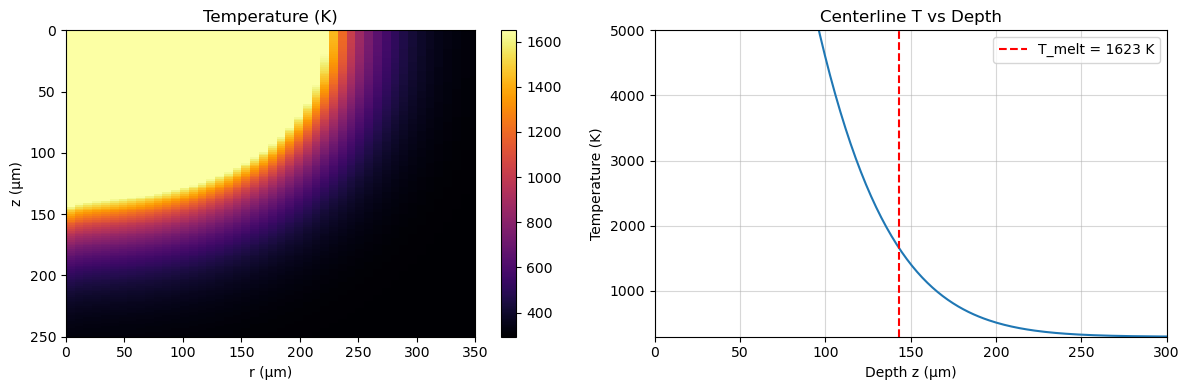

In [155]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 2D temperature map
im = axes[0].pcolormesh(r*1e6, z*1e6, T, cmap='inferno')
axes[0].set_xlabel('r (µm)')
axes[0].set_ylabel('z (µm)')
axes[0].set_title('Temperature (K)')
axes[0].set_xlim(0, 350)
axes[0].set_ylim(0, 250)
axes[0].invert_yaxis()
im.set_clim(None, 1650)
plt.colorbar(im, ax=axes[0])

# Centerline profile
axes[1].plot(z*1e6, T[:, 0])
axes[1].axvline(melt_depth*1e6, color='r', linestyle='--', label=f'T_melt = {T_melt:.0f} K')
# axes[1].axhline(293.15, color='k', linestyle='--', label='Room Temperature')
axes[1].set_xlabel('Depth z (µm)')
axes[1].set_ylabel('Temperature (K)')
axes[1].set_title('Centerline T vs Depth')
axes[1].set_xlim(0, 300)
axes[1].set_ylim(293.15, 5000)
axes[1].legend()
axes[1].grid(alpha=0.5)

plt.tight_layout()
plt.show()

## Eagar Tsai

Implementing the Eagar-Tsai heat flow problem for a moving heat source

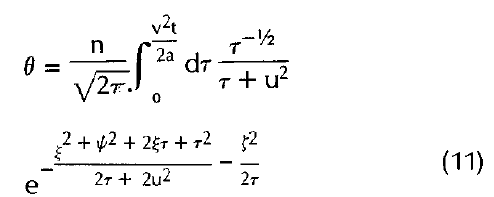

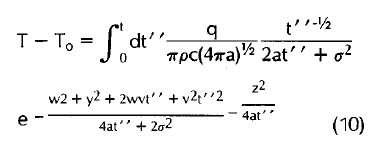

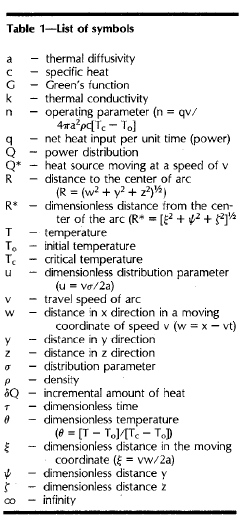

In [111]:
def solve_eagar_tsai(Xi, Psi, Zeta, n, u):
    """
    Solving the steady-state solution to Eagar-Tsai for a moving heat electron beam heat source
    """
    prefactor = n / np.sqrt(2 * np.pi)

    integral, _ = quad_vec(
        lambda tau: et_integrand_vec(tau, Xi, Psi, Zeta, u),
        0.0,
        np.inf,
        limit = 1000,
        epsabs=1e-6,
        epsrel=1e-6,
    )

    theta = prefactor * integral
    return theta

def et_integrand_vec(tau, Xi, Psi, Zeta, u):
    first = (1.0 / ((tau + u * u) * np.sqrt(tau)))
    exponent1 = ((Xi + tau)**2 + (Psi*Psi)) / (2 * (tau + u*u))
    exponent2 = (Zeta * Zeta) / (2 * tau)
    second = np.exp(-(exponent1 + exponent2))
    return first * second
    

In [119]:
## Parameters
# Material parameters
k = 20 # W/mK
rho = 7600 # kg/m3
cp = 600 # J/kg-K

alpha = k / (rho * cp) 

# Processing parameters
spot_size = 300 # um
r_beam = spot_size * 1e-6 / 2 # m
velocity = 1 # m/s
beam_current = 0.014 # A
beam_energy_eV = 50000 # eV
beam_area = np.pi * r_beam**2

# Simulation Parameters
T_c = 1350 + 273.15 # Critical temp (DSS melting point)
T_amb = 298 # Initial ambient temperature

x_max = 5 * r_beam
y_max = 5 * r_beam
z_max = 5 * r_beam

Nx = 101
Ny = 51
Nz = 51

x = np.linspace(-5*x_max, x_max, Nx)
y = np.linspace(-y_max, y_max, Ny)
z = np.linspace(0.0, z_max, Nz)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

Xi = X * velocity / (2 * alpha)
Psi = Y * velocity / (2 * alpha)
Zeta = Z * velocity / (2 * alpha)

# Derived Quantities
beam_power = beam_current * beam_energy_eV

# Eagar-Tsai Parameters
n = beam_power * velocity / (4 * np.pi * alpha * alpha * rho * cp * (T_c - T_amb)) # Operating parameter
u = velocity * r_beam / (2 * alpha)

## Solve
theta = solve_eagar_tsai(
    Xi, Psi, Zeta,
    n, u,
)

Temp = theta * (T_c + T_amb) + T_amb

print(f"Temperature field shape: {Temp.shape}")
print(f"Max T: {Temp.max():.2f}")

Temperature field shape: (101, 51, 51)
Max T: 13306.59


/tmp/ipykernel_1763/825374413.py:16: UserWarning: The following kwargs were not used by contour: 'linewidth'
  ax.contour(y_phys, x_phys, Temp[:, :, iz0], levels=[T_c], colors='cyan', linewidth=1.2)
/tmp/ipykernel_1763/825374413.py:26: UserWarning: The following kwargs were not used by contour: 'linewidth'
  ax.contour(z_phys, x_phys, Temp[:, iy0, :], levels=[T_c], colors='cyan', linewidth=1.2)


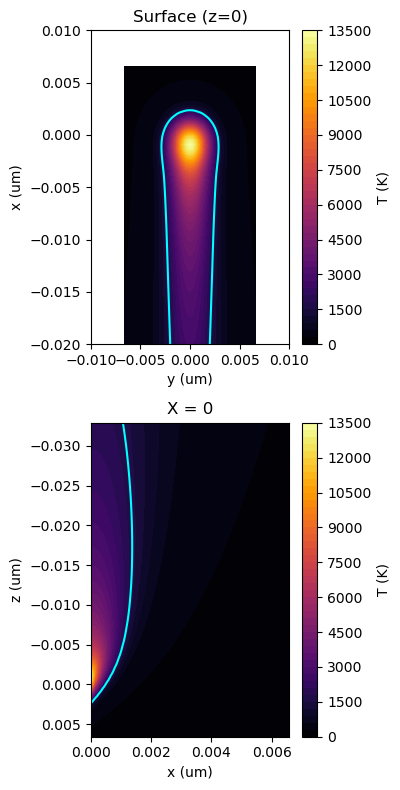

In [120]:
scale = 2 * alpha / velocity
x_phys = x * scale * 1e6
y_phys = y * scale * 1e6
z_phys = z * scale * 1e6

iz0 = 0
iy0 = np.argmin(np.abs(y_phys))
ix_peak = np.argmax(Temp[:, iy0, iz0])

fig, axes = plt.subplots(2, 1, figsize=(4, 8))

levels = 50

ax = axes[0]
cf = ax.contourf(y_phys, x_phys, Temp[:, :, iz0], levels=levels, cmap='inferno')
ax.contour(y_phys, x_phys, Temp[:, :, iz0], levels=[T_c], colors='cyan', linewidth=1.2)
fig.colorbar(cf, ax=ax, label='T (K)')
ax.set_xlabel('y (um)')
ax.set_ylabel('x (um)')
ax.set_title('Surface (z=0)')
ax.set_xlim(-0.01, 0.01)
ax.set_ylim(-0.02, 0.01)

ax = axes[1]
cf = ax.contourf(z_phys, x_phys, Temp[:, iy0, :], levels=levels, cmap='inferno')
ax.contour(z_phys, x_phys, Temp[:, iy0, :], levels=[T_c], colors='cyan', linewidth=1.2)
fig.colorbar(cf, ax=ax, label='T (K)')
ax.invert_yaxis()
ax.set_xlabel('x (um)')
ax.set_ylabel('z (um)')
ax.set_title('X = 0')

plt.tight_layout()
plt.show()